# Understanding Attrition Drivers for Employee Retention

This project aims to understand the main factors associated with employee attrition.
Employee turnover is an important concern for companies, as it can negatively impact productivity, team stability, and overall performance.

By identifying common patterns among employees who leave, this analysis seeks to provide insights that could support better retention decisions. 

## Business questions

The analysis focuses on the following questions:

- Which departments have the highest attrition rate?
- Is there a difference in average income between employees who leave and those who stay?
- How does overtime relate to employee attrition?
- Do employees who leave tend to have fewer years at the company?
- Do combinations of factors, such as overtime and low income, appear frequently among employees who leave?

### Starting by loading and analyzing the data

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("employee_attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


The Attrition column indicates whether an employee has left the company ("Yes")
or is still employed ("No") at the time the data was collected.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

The results show the proportion of employees who left the company compared to those
who remained employed at the time the data was collected.

Approximately 16% of employees left the company, indicating a moderately imbalanced
dataset. This distribution is typical in real organizational settings, where most
employees tend to stay and a smaller proportion leave.

## Attrition rate by departments

This section identifies the departments with the highest attrition rates,
which will be further analyzed to understand potential underlying patterns.

In [102]:
df_leavers = df.loc[df["Attrition"]=="Yes"]
df_stayers = df.loc[df["Attrition"]=="No"]

leavers_department = df_leavers.groupby("Department")["Attrition"].count() 
stayers_department = df_stayers.groupby("Department")["Attrition"].count() 

total_employee_department = leavers_department + stayers_department

attrition_rate_department = round((leavers_department / total_employee_department) * 100, 0)
attrition_rate_department

Department
Human Resources           19.0
Research & Development    14.0
Sales                     21.0
Name: Attrition, dtype: float64

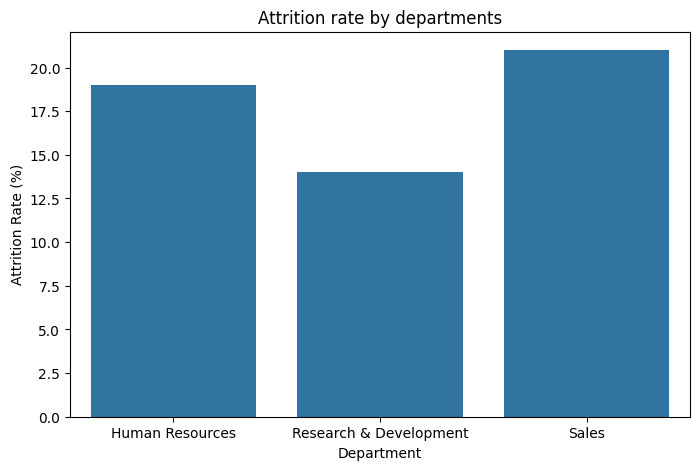

In [110]:
plt.figure(figsize=(8, 5))
plt.title("Attrition rate by departments")

sns.barplot(x=attrition_rate_department.index, y=attrition_rate_department.values)
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.show()

#### Sales Shows the Highest Attrition Rate

Sales shoes the highest attrition rate among departments, followed by Human Resources. 
Research & Development has a noticeably lower attrition rate, suggesting differences in job structure or work conditions across departments.

## Income leavers vs stayers

This section identifies if income is an important factor for those who leave and stay.
If the income is an important factor, then we can make many comparisons among departments to find patterns.

In [49]:
leavers_income = df_leavers["MonthlyIncome"].mean().round(2)
stayers_income = df_stayers["MonthlyIncome"].mean().round(2)
diff_income = (stayers_income - leavers_income).round(2)

print(f"Average monthly income for leavers: {leavers_income}")
print(f"Average monthly income for stayers: {stayers_income}")
print(f"Diffrence average income per month: {diff_income}")

Average monthly income for leavers: 4787.09
Average monthly income for stayers: 6832.74
Diffrence average income per month: 2045.65


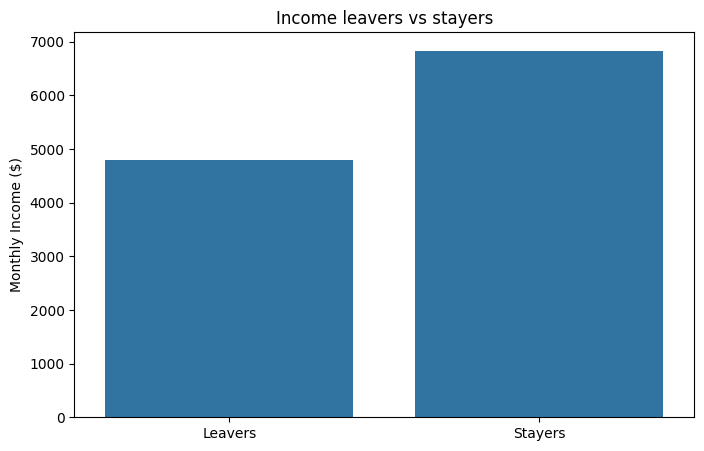

In [113]:
plt.figure(figsize=(8, 5))
plt.title("Average Monthly Income: Leavers vs Stayers")

sns.barplot(x=["Leavers", "Stayers"], y=[leavers_income, stayers_income])
plt.ylabel("Monthly Income ($)")
plt.show()

#### Lower Income Is Associated With Employee Attrition

The average monthly income is lower for employees who left the company than for
those who stayed, indicating that compensation may be a contributing factor to attrition.

## Overtime leavers vs stayers

In [69]:
df_leavers_overtime = df_leavers.loc[df_leavers["OverTime"]=="Yes"]
num_leavers_overtime = df_leavers_overtime["OverTime"].count()

df_stayers_overtime = df_stayers.loc[df_stayers["OverTime"]=="Yes"]
num_stayers_overtime = df_stayers_overtime["OverTime"].count()


leavers_overtime_pct = (num_leavers_overtime / df_leavers.shape[0] * 100).round(0)
stayers_overtime_pct = (num_stayers_overtime / df_stayers.shape[0] * 100).round(0)

diff_overtime = abs((stayers_overtime_pct - leavers_overtime_pct).round(0))

print(f"Percentage of leavers with overtime: {leavers_overtime_pct}%")
print(f"Percentage of stayers with overtime: {stayers_overtime_pct}%")
print(f"Diffrence of percentage overtime: {diff_overtime}%")

Percentage of leavers with overtime: 54.0%
Percentage of stayers with overtime: 23.0%
Diffrence of percentage overtime: 31.0%


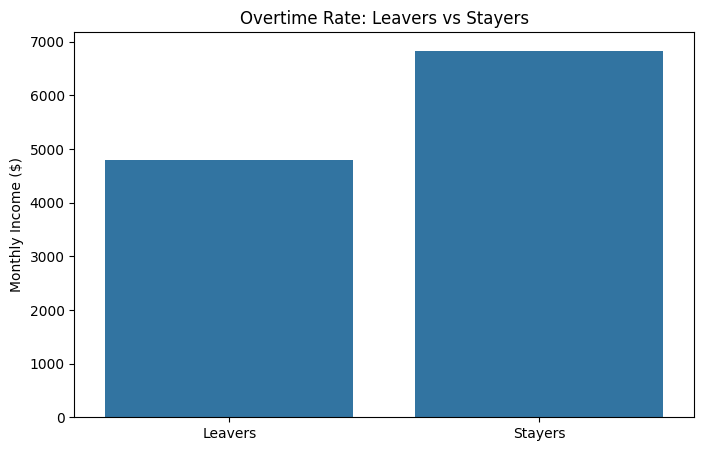

In [114]:
plt.figure(figsize=(8, 5))
plt.title("Overtime Rate: Leavers vs Stayers")

sns.barplot(x=["Leavers", "Stayers"], y=[leavers_income, stayers_income])
plt.ylabel("Monthly Income ($)")
plt.show()

#### Overtime Is More Common Among Employees Who Leave

Employees who left the company are significantly more likely to work overtime
compared to those who stayed. This suggests that overtime may be associated with higher attrition, particularly when combined with other factors.

## Overtime and Low Income Among Employees Who Left

Low income is defined as a monthly income below the company-wide average, providing a common reference point across all employees.

In [90]:
avg_monthly_income = df["MonthlyIncome"].mean().round(0)

leavers_lower_overtime_income = df_leavers_overtime.loc[df_leavers_overtime["MonthlyIncome"] < avg_monthly_income]
num_leavers_lower_overtime_income = leavers_lower_overtime_income["MonthlyIncome"].count()

leavers_lower_overtime_income_pct = (num_leavers_lower_overtime_income / df_leavers_overtime.shape[0] * 100).round(0)

print(f"Percentage of leavers who experienced both overtime and lower income: {leavers_lower_overtime_income_pct}%")

Percentage of leavers who experienced both overtime and lower income: 82.0%


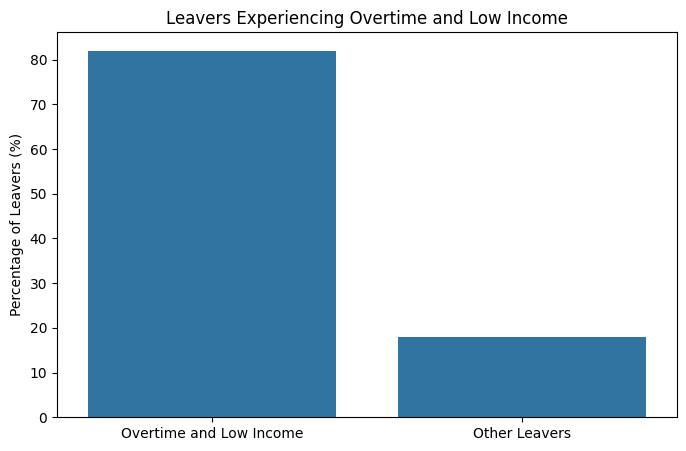

In [115]:
plt.figure(figsize=(8, 5))
plt.title("Leavers Experiencing Overtime and Low Income")

sns.barplot(x=["Overtime and Low Income", "Other Leavers"], y=[leavers_lower_overtime_income_pct, 100 - leavers_lower_overtime_income_pct])
plt.ylabel("Percentage of Leavers (%)")
plt.show()

#### Most Employees Who Leave Experience Both Overtime and Lower Income

A large share of employees who left the company experienced both overtime
and lower-than-average income. This suggets that the combination of increased 
workload and lower compensation may be associated with higher attrition risk.

## Years at company - leavers vs stayers

In [92]:
avg_years_leavers = df_leavers["YearsAtCompany"].mean().round(0)
avg_years_stayers = df_stayers["YearsAtCompany"].mean().round(0)

print(f"Average years at company for leavers: {avg_years_leavers}")
print(f"Average years at company for stayers: {avg_years_stayers}")

Average years at company for leavers: 5.0
Average years at company for stayers: 7.0


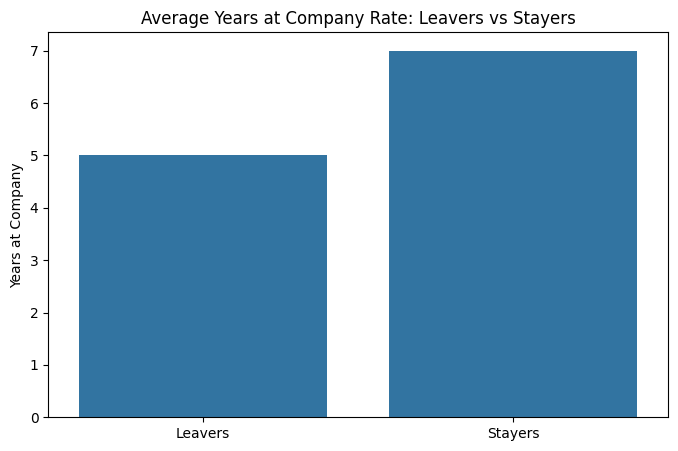

In [116]:
plt.figure(figsize=(8, 5))
plt.title("Average Years at Company Rate: Leavers vs Stayers")

sns.barplot(x=["Leavers", "Stayers"], y=[avg_years_leavers, avg_years_stayers])
plt.ylabel("Years at Company")
plt.show()

#### Attrition Is More Common Among Employees With Shorter Tenure

Employees who left the company tend to have fewer years of tenure compared to 
those who stayed. This suggests that attrition is more common among employees
in earlier stages of their employment.

This highlights the importance of early retention efforts during the first years
at the company.


## Income of leavers in Sales vs other departments

Because Sales department is the one with the highest attrition,
we analyze whether income differences may help explain attrition patterns across departments

In [96]:
income_leavers_by_department = df_leavers.groupby("Department")["MonthlyIncome"].mean().round(0)
income_leavers_by_department

Department
Human Resources           3716.0
Research & Development    4108.0
Sales                     5908.0
Name: MonthlyIncome, dtype: float64

Although Sales has the highest attrition rate, employees who leave the Sales
department do not have the lowest average income compared to other departments.
This suggests that factors other than compensation, such as workload or job pressure,
may play a more important role in attrition within Sales.

## Overtime Among Employees Who Left – Department Comparison

If income is not a factor for Sales employees to leave the company, 
is then overtime more common in Sales compared to other departments?

In [101]:
df_overtime_departments_leavers = df_leavers.loc[df["OverTime"]=="Yes"]

num_leavers_overtime_by_departments = df_overtime_departments_leavers.groupby("Department")["OverTime"].count()
total_num_leavers_overtime_or_not_by_departments = df_leavers.groupby("Department")["OverTime"].count()

pct_leavers_overtime_by_departments = (num_leavers_overtime_by_departments / total_num_leavers_overtime_or_not_by_departments * 100).round(0)
pct_leavers_overtime_by_departments

Department
Human Resources           42.0
Research & Development    56.0
Sales                     52.0
Name: OverTime, dtype: float64

Although Sales has the highest overall attrition rate, overtime among employees
who left the company is not significantly higher in Sales compared to other
departments. This suggests that overtime alone does not fully explain the higher
attrition observed in Sales.

This indicates that additional factors, such as job pressure or role-specific
demands, may contribute to attrition patterns in Sales.

## Synthesis of Findings

The analysis highlights several consistent patterns related to employee attrition.

Sales shows the highest attrition rate among departments, which indicated department specific challenges. But Sales didn't show the lowest income rate or the highest overtime rate among departments. This suggests that there is a possibility for other additional factors to contribute to attrition patterns in Sales.
Across the company, employees who left tend to have lower monthly income and are more likely
to work overtime compared to those who stayed.

Additionally, a large share of leavers experienced both overtime and below-average income,
suggesting that workload combined with compensation may play an important role in attrition.
Finally, employees who leave the company tend to have fewer years of tenure, indicating that
attrition is more common in earlier stages of employment.

## Recommendations

Based on the findings, the following actions could support employee retention:

- Review workload and overtime policies, particularly in departments with higher attrition,
  to reduce sustained overtime pressure.
- Evaluate compensation levels for employees with lower income, especially when combined
  with high workload.
- Strengthen onboarding and early retention initiatives, as attrition appears more common
  during the first years at the company.